# Classification

### import required packages

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### load the data

In [50]:
df = pd.read_csv('./hearing_test.csv')
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


### exploratory data anylysis

In [51]:
# get general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [52]:
# get statistical info
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [53]:
# correlation analysis
df.corr()

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


In [54]:
# check if there is any missing records
df.isna().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [55]:
# check if the dataset is balanced
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

### data preparation

In [56]:
# split the data into x and y
x=df.drop(['test_result'],axis=1)
y=df['test_result']

In [57]:
# balance the dataset

from imblearn.over_sampling import SMOTE

# create SMOTE object
smote = SMOTE()

# create oversampled dataset
x_new, y_new = smote.fit_resample(x, y)

In [58]:
# check if the dataset is balanced
y_new.value_counts()

test_result
1    3000
0    3000
Name: count, dtype: int64

In [59]:
# split the data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_new,y_new,train_size=0.7,random_state=42)

### train the models

In [60]:
from sklearn.tree import DecisionTreeClassifier
# create a model
model = DecisionTreeClassifier(max_depth=3)

# train the model
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

### evaluate the model

In [61]:
from sklearn.metrics import accuracy_score  , precision_score , recall_score , f1_score

# predict the train model
y_pred = model.predict(x_train)

accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print(f"accuracy = {accuracy:.2f}")
print(f"precision = {precision:.2f}")
print(f"recall = {recall:.2f}")
print(f"f1 = {f1:.2f}")

accuracy = 0.92
precision = 0.90
recall = 0.94
f1 = 0.92


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# predict the test dataset
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"accuracy = {accuracy:.2f}")
print(f"precision = {precision:.2f}")
print(f"recall = {recall:.2f}")
print(f"f1 = {f1:.2f}")

accuracy = 0.90
precision = 0.89
recall = 0.92
f1 = 0.91


### visulaize the tree

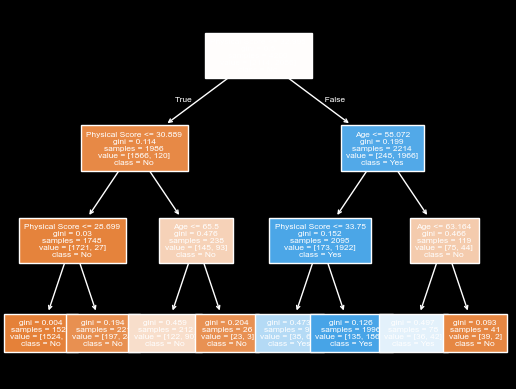

In [63]:
from sklearn.tree import  plot_tree
#visualize
_ = plot_tree(
     model,
     feature_names=['Age','Physical Score'],
     class_names=['No', 'Yes'],
     fontsize=6,
     filled=True)
